In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams['figure.figsize']=(10, 6)

In [18]:
df=pd.read_csv("dataset.csv")
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [19]:
print("Shape:",df.shape)
df.info()

Shape: (114000, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  

In [21]:
numerical_cols=df.select_dtypes(include=np.number).columns.tolist()
categorical_cols=df.select_dtypes(include='object').columns.tolist()
print("Numerical features:", numerical_cols)
print("Categorical features:", categorical_cols)

Numerical features: ['Unnamed: 0', 'popularity', 'duration_ms', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']
Categorical features: ['track_id', 'artists', 'album_name', 'track_name', 'track_genre']


In [5]:
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [22]:
print("Missing values:\n",df.isnull().sum())
print("\nDuplicate rows:",df.duplicated().sum())
df=df.drop_duplicates()
df=df.dropna()

Missing values:
 Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

Duplicate rows: 0


In [23]:
corr=df[numerical_cols].corr()
corr

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
Unnamed: 0,1.000000,0.032146,-0.032738,0.003445,-0.055993,-0.005521,-0.027307,0.005110,-0.084952,0.076837,-0.070285,0.033641,0.053109,-0.025825,-0.021115
popularity,0.032146,1.000000,-0.007129,0.035444,0.001053,-0.003847,0.050420,-0.013948,-0.044930,-0.025458,-0.095147,-0.005397,-0.040522,0.013212,0.031076
duration_ms,-0.032738,-0.007129,1.000000,-0.073435,0.058520,0.008123,-0.003475,-0.035581,-0.062605,-0.103770,0.124364,0.010308,-0.154464,0.024356,0.018229
danceability,0.003445,0.035444,-0.073435,1.000000,0.134325,0.036470,0.259076,-0.069224,0.108625,-0.171531,-0.185608,-0.131620,0.477347,-0.050448,0.207219
energy,-0.055993,0.001053,0.058520,0.134325,1.000000,0.048007,0.761690,-0.078365,0.142508,-0.733908,-0.181880,0.184795,0.258937,0.247852,0.187127
key,-0.005521,-0.003847,0.008123,0.036470,0.048007,1.000000,0.038591,-0.135911,0.020419,-0.040942,-0.006821,-0.001597,0.034099,0.010914,0.015064
loudness,-0.027307,0.050420,-0.003475,0.259076,0.761690,0.038591,1.000000,-0.041768,0.060826,-0.589804,-0.433478,0.076897,0.279851,0.212447,0.191992
mode,0.005110,-0.013948,-0.035581,-0.069224,-0.078365,-0.135911,-0.041768,1.000000,-0.046535,0.095568,-0.049961,0.014004,0.021964,0.000572,-0.024090
speechiness,-0.084952,-0.044930,-0.062605,0.108625,0.142508,0.020419,0.060826,-0.046535,1.000000,-0.002184,-0.089617,0.205218,0.036637,0.017274,-0.000011
acousticness,0.076837,-0.025458,-0.103770,-0.171531,-0.733908,-0.040942,-0.589804,0.095568,-0.002184,1.000000,0.104033,-0.020693,-0.107081,-0.208231,-0.176142


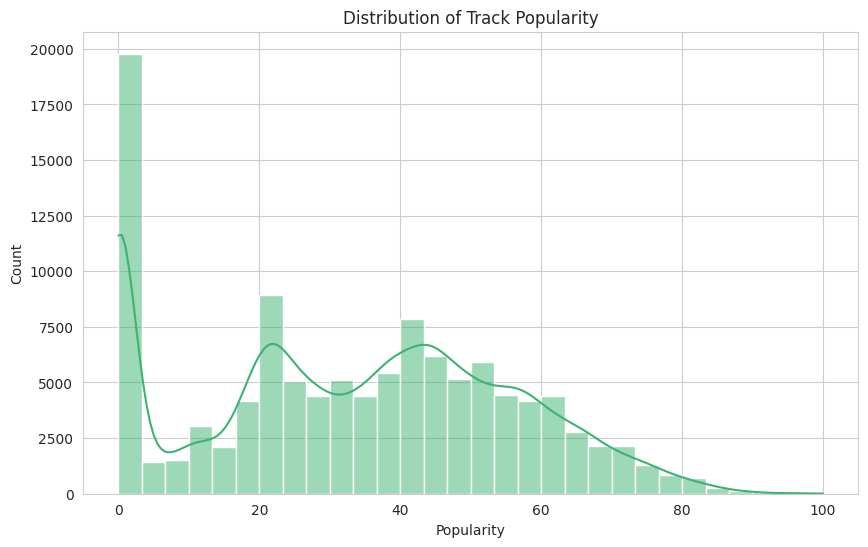

In [24]:
plt.figure()
sns.histplot(df['popularity'], bins=30, kde=True,color='mediumseagreen')
plt.title("Distribution of Track Popularity")
plt.xlabel("Popularity")
plt.show()
# Insight: Popularity is heavily right-skewed, with a large spike near 0 (~20,000 tracks with almost no plays), likely unreleased/obscure tracks. The rest of the distribution is fairly spread out with mild peaks around 20, 40, and 50 and a long tail toward 100, meaning very few tracks are truly "hit" popular.

/tmp/ipykernel_2697/82425729.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis')


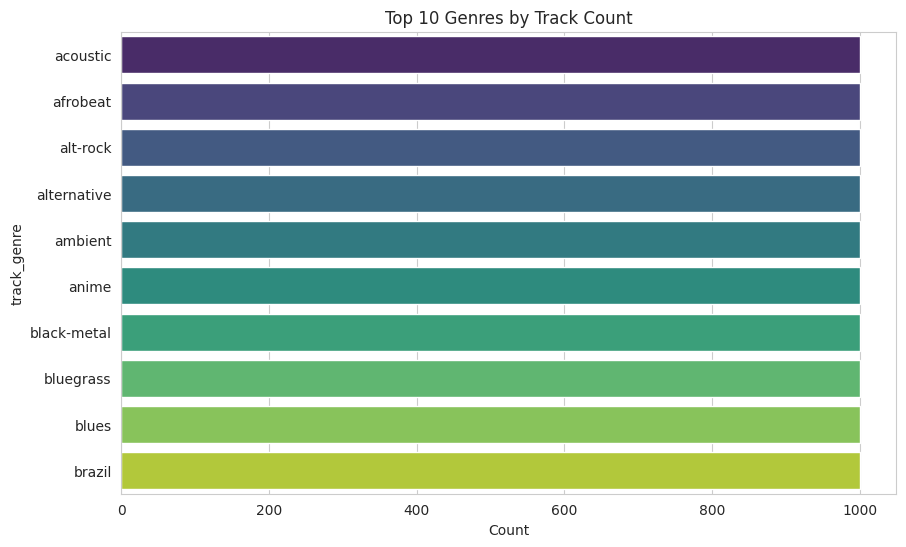

In [25]:
plt.figure()
top_genres= df['track_genre'].value_counts().head(10)
sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis')
plt.title("Top 10 Genres by Track Count")
plt.xlabel("Count")
plt.show()
# Insight: All genres shown have nearly identical counts. This confirms the dataset is artificially balanced, roughly 1,000 tracks per genre, so genre popularity comparisons reflect track characteristics, not sampling bias.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


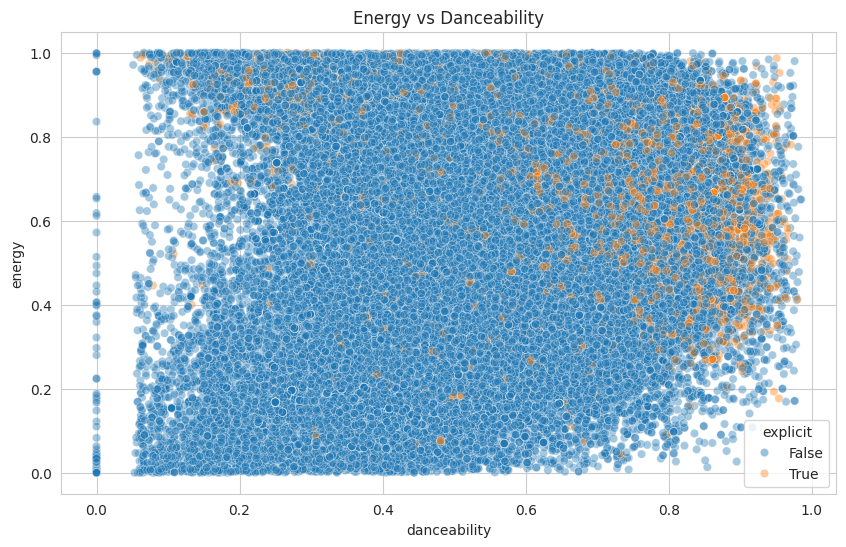

In [26]:
plt.figure()
sns.scatterplot(data=df,x='danceability', y='energy', alpha=0.4,hue='explicit')
plt.title("Energy vs Danceability")
plt.show()
# Insight: No strong linear relationship between danceability and energy, points are spread across the full range. Explicit tracks (orange) cluster more toward higher danceability and energy, suggesting explicit content trends toward livelier tracks.

/tmp/ipykernel_2697/79251023.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='explicit', y='loudness',palette='coolwarm')


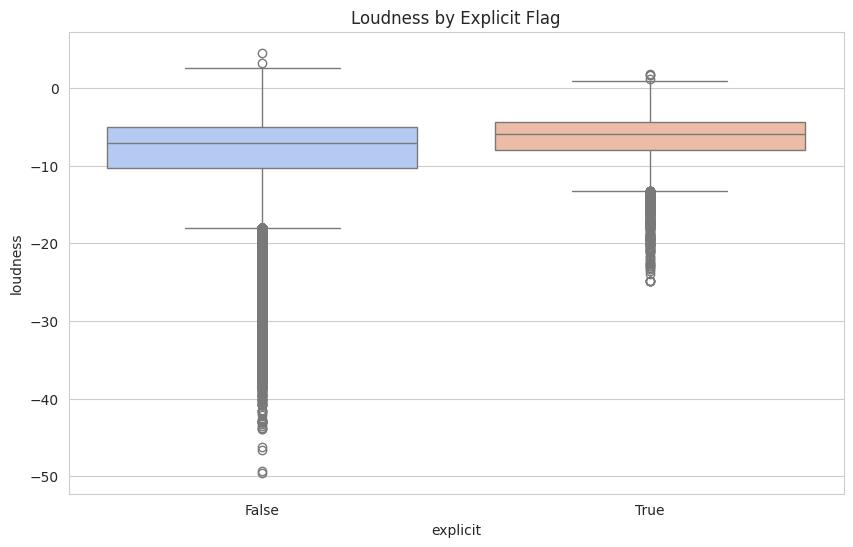

In [27]:
plt.figure()
sns.boxplot(data=df, x='explicit', y='loudness',palette='coolwarm')
plt.title("Loudness by Explicit Flag")
plt.show()
# Insight: Explicit tracks have a noticeably higher median loudness and a tighter distribution, while non-explicit tracks show a wider spread with many low-loudness outliers (down to -40 dB), likely quiet acoustic/ambient tracks.

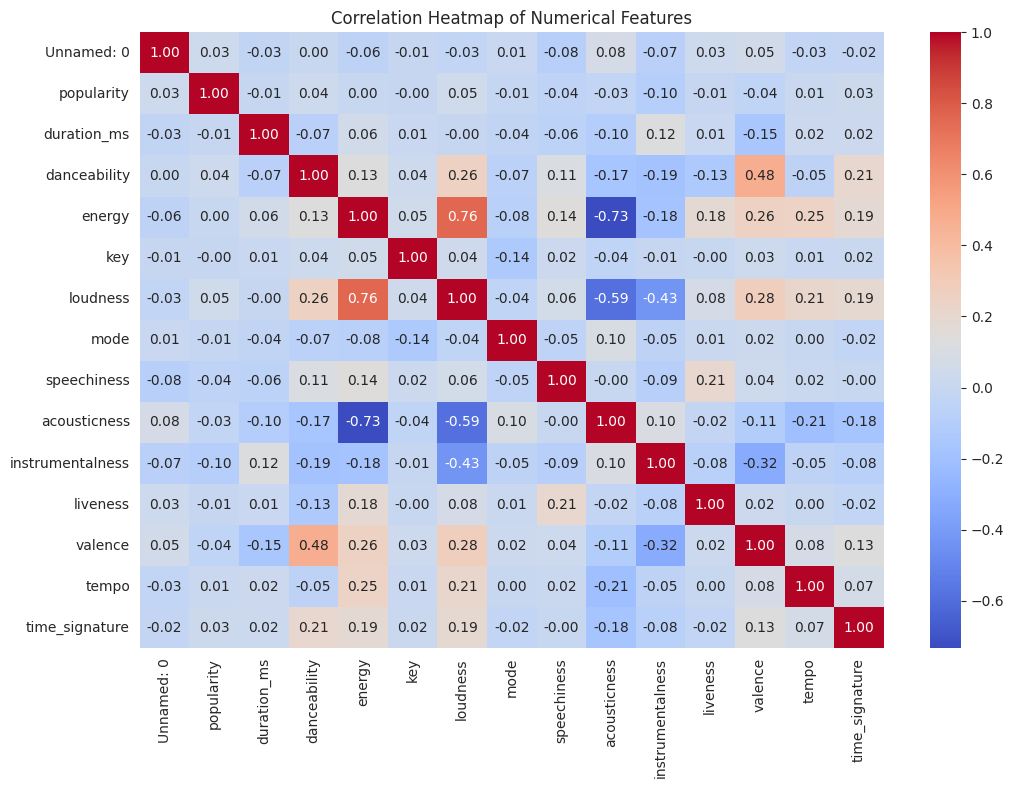

In [28]:
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap of Numerical Features")
plt.show()
# Insight: Energy and loudness are strongly positively correlated (0.76), louder tracks tend to be more energetic. Energy and acousticness are strongly negatively correlated (-0.73), and loudness vs acousticness is also strongly negative (-0.59). Danceability and valence show a moderate positive link (0.48), meaning danceable tracks tend to sound happier.

/tmp/ipykernel_2697/3923378954.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=subset, x='track_genre', y='valence', palette='pastel')


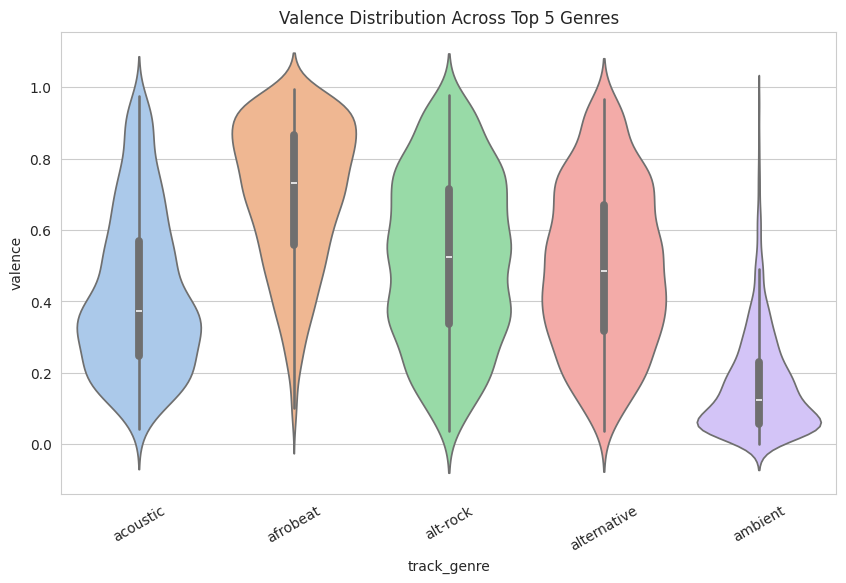

In [29]:
top5 = df['track_genre'].value_counts().head(5).index
subset = df[df['track_genre'].isin(top5)]
plt.figure()
sns.violinplot(data=subset, x='track_genre', y='valence', palette='pastel')
plt.title("Valence Distribution Across Top 5 Genres")
plt.xticks(rotation=30)
plt.show()
# Insight: Afrobeat skews distinctly happier (high median valence, ~0.75+), while ambient skews distinctly sadder/moodier (low median valence, ~0.3). Acoustic, alt-rock and alternative show wide, evenly spread valence, meaning mood varies a lot within those genres rather than leaning one way.

Summary of Findings

1. Popularity is heavily skewed, most tracks have low-to-moderate popularity, and only a small fraction achieve high popularity scores.
2. The dataset is genre-balanced (~1,000 tracks per genre across 114 genres), making cross-genre comparisons fair and unbiased.
3. Energy and loudness are the most tightly linked audio features (r = 0.76), while energy and acousticness move in opposite directions (r = -0.73), acoustic tracks are inherently quieter and less energetic.
4. Explicit tracks tend to be louder and more energetic/danceable than non-explicit tracks.
5. Mood (valence) varies strongly by genre, afrobeat is the happiest-sounding genre among the top 5, ambient is the calmest/saddest, while acoustic, alt-rock, and alternative span the full emotional range.
6. Audio "feel" (energy, loudness, acousticness, valence) is more genre-dependent than popularity is, popularity appears driven more by external factors like artist fame and marketing rather than the song's audio characteristics alone.